### Weather data visualisation

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# loading dataset
data = pd.read_csv('./data/cambodia 2024-01-01 to 2024-12-31.csv')
data[:3]

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,cambodia,2024-01-01,91.2,77.4,84.5,94.9,77.4,89.2,72.0,67.8,...,17.4,7,10,2024-01-01T06:19:59,2024-01-01T17:47:30,0.67,"Rain, Partially cloudy",Partly cloudy throughout the day with rain in ...,rain,"48992099999,VDPP,48991099999,48997099999"
1,cambodia,2024-01-02,91.8,78.3,84.9,97.1,78.3,88.8,70.3,62.9,...,19.1,8,10,2024-01-02T06:20:23,2024-01-02T17:48:03,0.70,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"48992099999,VDPP,48991099999,48997099999"
2,cambodia,2024-01-03,91.4,78.4,84.8,95.4,78.4,88.3,69.5,61.2,...,19.1,8,10,2024-01-03T06:20:46,2024-01-03T17:48:36,0.73,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"48992099999,VDPP,48991099999,48997099999"


/var/folders/z6/2wz7jxb56936gt0mxv3lscnm0000gn/T/ipykernel_83162/1365603951.py:18: FutureWarning: The provided callable <function mean at 0x106f44220> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  heatmap_data = data.pivot_table(


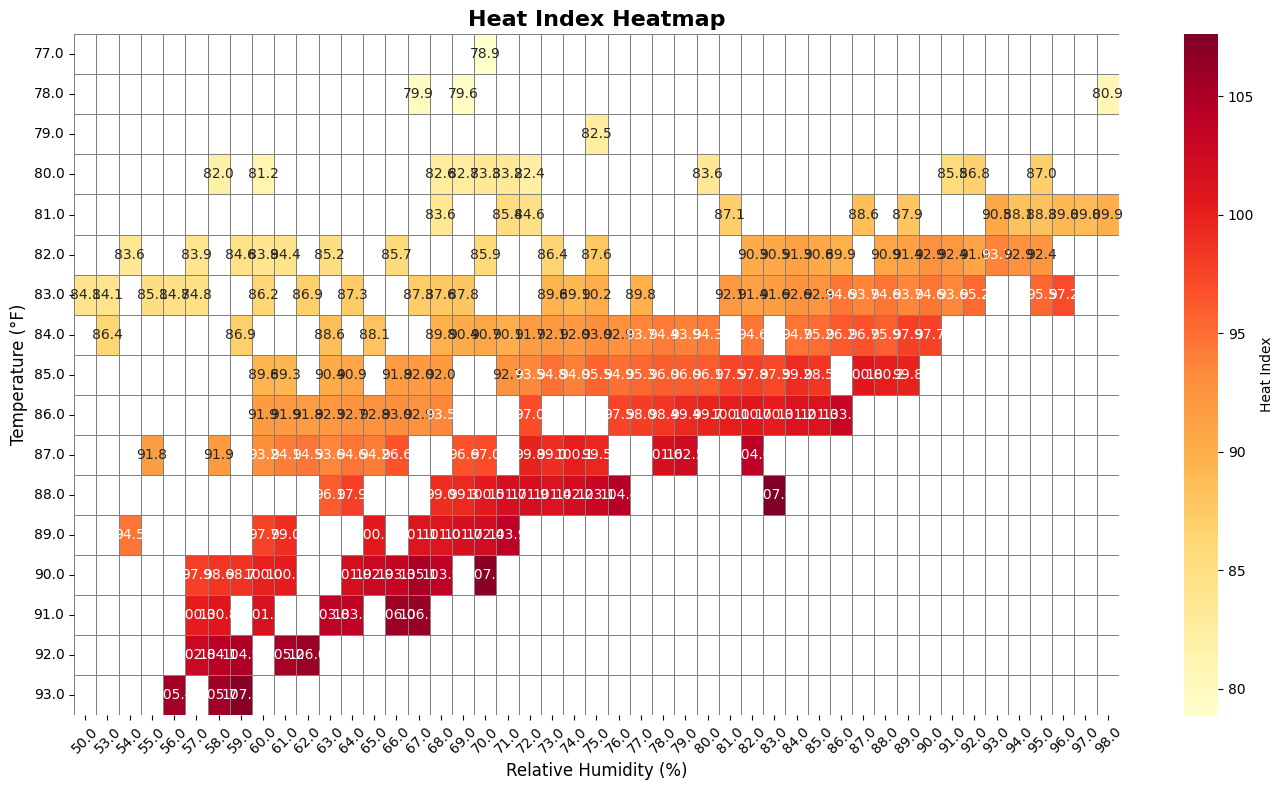

In [4]:
# Define the heat index calculation function
def calculate_heat_index(temp, humidity):
    # Temperature and humidity in the heat index formula
    HI = -42.379 + 2.04901523 * temp + 10.14333127 * humidity \
         - 0.22475541 * temp * humidity - 0.00683783 * temp**2 \
         - 0.05481717 * humidity**2 + 0.00122874 * temp**2 * humidity \
         + 0.00085282 * temp * humidity**2 - 0.00000199 * temp**2 * humidity**2
    return HI

# Calculate heat index
data['heat_index'] = data.apply(lambda row: calculate_heat_index(row['temp'], row['humidity']), axis=1)

# Round temperature and humidity for grouping
data['temp_rounded'] = data['temp'].round()
data['humidity_rounded'] = data['humidity'].round()

# Create a pivot table for heatmap
heatmap_data = data.pivot_table(
    index='temp_rounded',
    columns='humidity_rounded',
    values='heat_index',
    aggfunc=np.mean
)

# Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=True,
    fmt=".1f",
    cbar_kws={'label': 'Heat Index'},
    linewidths=0.5,  # Adds gridlines for separation
    linecolor='gray'
)

# Adjust axis labels for better readability
plt.title("Heat Index Heatmap", fontsize=16, weight='bold')
plt.xlabel("Relative Humidity (%)", fontsize=12)
plt.ylabel("Temperature (°F)", fontsize=12)

# Rotate x-axis labels for clarity
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

/var/folders/z6/2wz7jxb56936gt0mxv3lscnm0000gn/T/ipykernel_83162/2704211178.py:17: FutureWarning: The provided callable <function mean at 0x106f44220> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  heatmap_data = data.pivot_table(


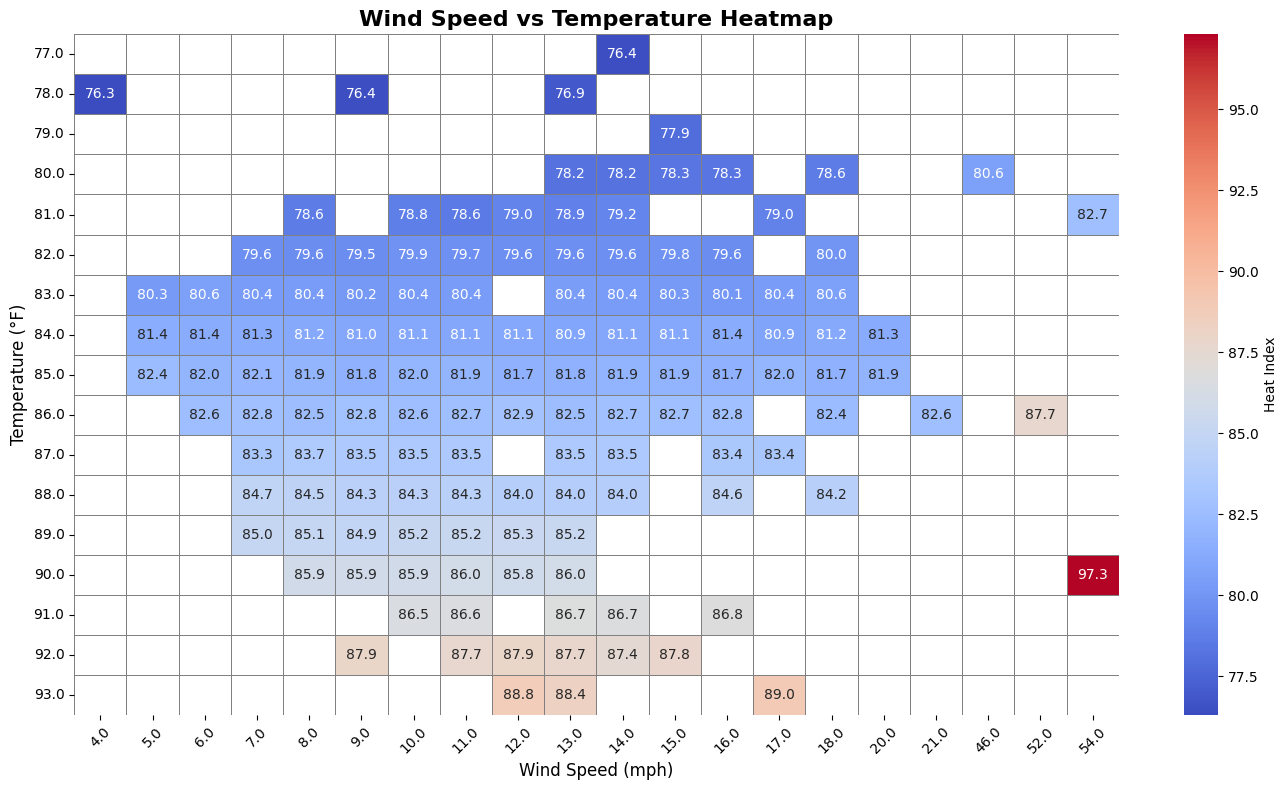

In [9]:
# Round temperature and wind speed to create bins
data['temp_rounded'] = data['temp'].round()
data['wind_speed_rounded'] = data['windspeed'].round()

# Define the heat index calculation function
def calculate_heat_index(temp, windspeed):
    # Temperature and windspeed in the heat index formula
    HI = -42.379 + 2.04901523 * temp + 10.14333127 * windspeed \
         - 0.22475541 * temp * windspeed - 0.00683783 * temp**2 \
         - 0.05481717 * windspeed**2 + 0.00122874 * temp**2 * windspeed \
         + 0.00085282 * temp * windspeed**2 - 0.00000199 * temp**2 * windspeed**2
    return HI

# Calculate heat index
data['temp_windspeed_heat_index'] = data.apply(lambda row: calculate_heat_index(row['temp'], row['windspeed']), axis=1)
# Create a pivot table with temperature and wind speed
heatmap_data = data.pivot_table(
    index='temp_rounded',
    columns='wind_speed_rounded',
    values='temp_windspeed_heat_index',  # Aggregating temperature itself (you can choose another metric if desired)
    aggfunc=np.mean
)

# Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',  # Adjust the colormap for better representation
    annot=True,       # Show numerical values in the heatmap cells
    fmt=".1f",        # Format numbers to one decimal place
    cbar_kws={'label': 'Heat Index'},  # Add a colorbar label
    linewidths=0.5,   # Add gridlines for clarity
    linecolor='gray'
)

# Customize axis labels and title
plt.title("Wind Speed vs Temperature Heatmap", fontsize=16, weight='bold')
plt.xlabel("Wind Speed (mph)", fontsize=12)
plt.ylabel("Temperature (°F)", fontsize=12)

# Rotate axis labels for better readability
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Optimize layout
plt.tight_layout()
plt.show()
